In [ ]:
import pwr_rei_template as pwr
import openmc
import openmc.deplete
import numpy as np
import copy
import pickle as pkl
import glob
import os
openmc.deplete.pool.USE_MULTIPROCESSING=False

"""
Depletion scheme for explicit euler. Meant to just get cross sections at the very end for reuse later.
"""

class Regression():
  def __init__(self):
    pass

  def get_avg(self, res: dict, val: float):
    """
    gets average from a results dict.
    Note that res must be ran through self.tally_by_gen
    before the averages can be computed.

    Parameters
    ==========
    res : dict
      batch-by-batch estimate of the flux (each batch represents a single trial)
    val : float
      what to normalize the output flux to

    Returns
    =======
    flux : np.array
      the normalized average flux (norm'd across all gens)
    """
    flux = np.zeros(len(res[0]))
    for key in res.keys():
      # Get the normalized flux (this batches estimate for flux)
      the_unnorm_flux = res[key]
      sum_unnorm = np.sum(the_unnorm_flux)
      if sum_unnorm > 0:
        the_normd_flux = the_unnorm_flux/sum_unnorm * val
        flux += the_normd_flux
    flux *= val / np.sum(flux)
    return flux

  def write_res_pkl(self, res: dict, file:str):
    with open(file, 'wb') as f:
      pkl.dump(res, file)

  def tally_by_gen(self, res: dict):
    """does a quick cleanup after running transport"""
    theLength = res[0].__len__()
    shape0 = np.zeros(theLength)
    d = {}
    """nice little function to get tallies by gen"""
    for key in res.keys():
      shape1 = np.array([ this[:,:,1][0][0] for this in res[key][0:theLength] ])
      shape = shape1 - shape0
      d[key] = shape
      # advance
      shape0 = shape1
    return d

  def normalize_res(self, res: dict, val: float):
    """normalizes res dictionary to some value"""
    for key in res.keys():
      the_sum = np.sum(res[key])
      if the_sum == 0:
        res[key] = res[key]
      else:
        res[key] = res[key] / the_sum * val
    return res

  def _get_vij(self, N: int, start: int, F: list, I: list,
              i: int, j: int, f: int):
    Vij = 0.0
    for k in range(start,start+N):
      Vij += (F[i][k][f] - I[i][f])*(F[j][k][f] - I[j][f]) / (N-1)
    return Vij

  def get_new_I(self, N: int, start: int,
                F: list, I: list,
                f: int):
    """
    Parameters
    ==========
    N : int
      number active histories

    start : int
      starting aka nSkipped

    F : list
      list of res dicts (F1, F2, F3, ...)

    I : list
      list of final I values (normalized?)

    f : int
      tally id number to operate on.

    Returns
    =======
    new_I : float
      the new value of I corresponding to tally id f
    coeff : float
      the correlation coefficient

    """
    n = len(F)
    V = np.zeros((n,n))
    for i in range(n):
      for j in range(n):
        V[i,j] = self._get_vij(N=N, start=start, F=F, I=I, i=i, j=j, f=f) # returns vectror of Vij where each index is a fuel zone

    print("the matrix V is")
    print(V)
    if n == 2:
      # print correlation a and b
      coeff = V[1,0]/V[0,0]**0.5/V[1,1]**0.5
      print("the correlation coeff = ", coeff)
    else:
      coeff = 0
    the_I = np.array([[this[f] for this in I]]).transpose() # col vec of my best estimates.
    X = np.ones((n,1)) # col vec of ones.
    M = np.linalg.inv(X.transpose() @ np.linalg.inv(V) @ X) @ X.transpose() @ np.linalg.inv(V)
    print("\nThe matrix is: ", M, "\n")
    new_I = M @ the_I
    return new_I, coeff

def run_transport_for_chain(model: openmc.Model, chain_file: str):
  """runs an openmc transport calculation for getting the depletion chain"""
  able_mats = depletable_mats_from_model(model) # get the depletable materials (so we can tally)
  fluxes, micros = openmc.deplete.get_microxs_and_flux(model, able_mats, chain_file=chain_file)
  return fluxes, micros

def run_transport(model: openmc.Model, power_tally_ids: list):
  """runs an openmc transport calculation while doing batch-by-patch tallies"""
  # Clear xml's
  for file in glob.glob("*.xml"):
    os.remove(file)
  # export model
  model.export_to_xml()
  res = {} # contains/stores power tally ids and stuff like that.
  settings = model.settings

  openmc.lib.init()
  openmc.lib.simulation_init()
  for b in range(settings.batches):
    tallies = [openmc.lib.tallies[the_id] for the_id in power_tally_ids]
    openmc.lib.next_batch()
    results = [tally.results for tally in tallies]
    res[b] = copy.deepcopy(results)
  openmc.lib.simulation_finalize()
  openmc.lib.finalize()
  return res

def depletable_mats_from_model(model: openmc.Model) -> openmc.Materials:
  """get depletable materials as openmc.Materials object"""
  depletable_mats = []
  for this in model.materials:
    if this.depletable:
      depletable_mats.append(this)
  depletable_mats = openmc.Materials(depletable_mats)
  return depletable_mats

def get_nuclides_for_transport(chain_file: str, model: openmc.Model):
  from openmc.deplete.coupled_operator import _find_cross_sections, _get_nuclides_with_data
  from openmc.deplete.chain import Chain
  chain = Chain.from_xml(chain_file)
  cross_sections = _find_cross_sections(model)
  nuclides_with_data = _get_nuclides_with_data(cross_sections)
  nuclides = [nuc.name for nuc in chain.nuclides
              if nuc.name in nuclides_with_data]
  return nuclides

def make_transport_material_library(output_name: str, model: openmc.Model, chain_file: str):
  """
  Function to take in a model, chain, and reults file.

  Updates the model.materials to be the transport materials
  with the latest results from results file. Inline modification
  of the materials

  Only considers transport nuclides though.
  """

  # Make transport material library.

  results = openmc.deplete.Results(output_name)
  transport_mats = []

  # Depletables
  trans_nuc_list = get_nuclides_for_transport(chain_file=chain_file, model=model)
  for mat in model.materials:
    if not mat.depletable:
      continue # skip if not depletable

    # Make a new material for the depletables
    new_mat = openmc.Material(mat.id, mat.name, temperature=mat.temperature)
    new_mat.volume = mat.volume
    new_mat.depletable = True
    for nuc in trans_nuc_list:
      perc = results.get_atoms(mat=mat, nuc=nuc, nuc_units='atom/b-cm')[-1][-1]
      new_mat.add_nuclide(nuclide=nuc, percent=perc, percent_type='ao')
      new_mat.set_density(units='sum')
    transport_mats.append(new_mat)

  # Nondepletables, can just append what we have already
  for mat in model.materials:
    if not mat.depletable:
      transport_mats.append(mat)

  new_lib = openmc.Materials(transport_mats)
  # new_lib.export_to_xml()
  model.materials = new_lib

def get_depletion_materials_from_results_EOS(output_name: str, model: openmc.Model):
  """
  Function for getting materials for depletion EOS values (or BOS for the next step)
  Returns a list of materials marked depletable
  with full depletion chain.

  No inline modification of models object.
  """
  results = openmc.deplete.Results(output_name)
  depletion_mat_list = []
  for mat in model.materials:
    if mat.depletable:
      eos_mat = results[-1].get_material(str(mat.id))
      depletion_mat_list.append(eos_mat)
  return openmc.Materials(depletion_mat_list)

def chain_from_pkl(file: str):
  with open(file, 'rb') as f:
    fakeFluxes, chain = pkl.load(f)
    if len(chain) == 1:
      new_chain = []
      for this in range(16):
        new_chain.append(copy.deepcopy(chain[0]))
      return new_chain
    else:
      return chain

Matplotlib is building the font cache; this may take a moment.


[ 11.4375  34.3125  57.1875  80.0625 102.9375 125.8125 148.6875 171.5625
 194.4375 217.3125 240.1875 263.0625 285.9375 308.8125 331.6875 354.5625]


/Users/4yf/projects/MonteCarloXenon/.pixi/envs/default/lib/python3.13/site-packages/openmc/stats/multivariate.py:960: FutureWarning: The 'only_fissionable' has been deprecated. Use the 'constraints' argument when defining a source instead.
  warn("The 'only_fissionable' has been deprecated. Use the "


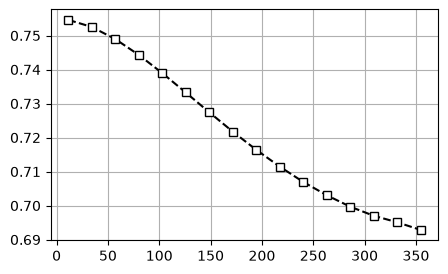

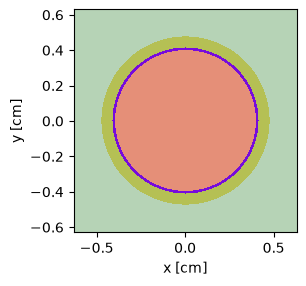

In [ ]:
"""some random settings"""
fuel_r=0.3975
power_density = 104
power = power_density * 366  * np.pi * fuel_r**2
dt = [0.5, 1, 1.5, 2, 5, 10, 20] # up to 20 days
iterations = 1 # number of iterations we run (so +1 to this for total # transports)
Nstart = 1
Nactive = 9

"""get the model"""
model = pwr.get_model()
chain_file = '../chain_casl_pwr.xml'

"""regression class"""
regr =  Regression()

"""run explicit euler depletion scheme"""
depletion_materials = depletable_mats_from_model(model=model) # get from starting model
depl_id_list = [this.id for this in depletion_materials]

In [ ]:
"""
T0 transport and get fluxes
"""
d = run_transport(model=model, power_tally_ids=depl_id_list) ## this one tracks batch-by-batch
res = regr.tally_by_gen(res=d)
res_normd = regr.normalize_res(res=res, val=1.0)
last_shape = res_normd[max(list(res_normd.keys()))]
fluxes = last_shape # todo might have to do something to this shape but just get the last one is ok.
# _fakefluxes, micro_xs = run_transport_for_chain(model=model, chain_file=chain_file) # todo load reference xs here instead
micro_xs = chain_from_pkl(file='../chain_gen/FINAL.pkl') # get xs from a reference file

for idx, this_dt in enumerate(dt):
  res_list = []
  I = []
  for ni in range(iterations+1):
    """Start w/ predicting forward in time with most recent fluxes"""
    # Deplete (operator setup and then deplete)
    output_name = f"depl_step_s{idx}_i{ni}.h5"
    print("Now depleting with flux =", fluxes)
    op = openmc.deplete.IndependentOperator(depletion_materials, fluxes, micro_xs, chain_file=chain_file)
    openmc.deplete.PredictorIntegrator(op, timesteps=[this_dt], power=power, timestep_units='d').integrate(path=output_name)

    # Now update the transport materials (inline modify model.materials)
    make_transport_material_library(output_name=output_name, model=model, chain_file=chain_file)
    d = run_transport(model=model, power_tally_ids=depl_id_list) ## this one for res tracking...
    res =  regr.tally_by_gen(res=d)
    regr.write_res_pkl(res=res, file=f'res_s{idx}_i{ni}.pkl')
    res_normd = regr.normalize_res(res=res, val=1.0)
    last_shape = res_normd[max(list(res_normd.keys()))]
    fluxes = last_shape # todo might have to do something to this shape but just get the last one is ok.
    I.append(copy.deepcopy(fluxes))
    res_list.append(res_normd)

    # Corrector fluxes or keep them as is (correct if ni is above 0)
    if ni > 0:
      fluxes = []
      for f in depl_id_list: # go thorugh fList and get all the newly predicted fluxes.. note that tally id's have same ids as depl materials
        flux_f = regr.get_new_I(N=Nactive, start=Nstart, F=res_list, I=I, f=f)
        fluxes.append(flux_f)
    else:
      fluxes = fluxes

  # Now make the depletion materials BOS for the next depletion step...
  depletion_materials = get_depletion_materials_from_results_EOS(output_name=output_name, model=model)

the matrix V is
[[ 2.39797004e-07 -2.83942717e-08]
 [-2.83942717e-08  5.65555768e-07]]
the correlation coeff =  -0.07710297551188652

The matrix is:  [[0.68892423 0.31107577]] 

the matrix V is
[[8.43231396e-07 1.42645678e-07]
 [1.42645678e-07 2.14625106e-06]]
the correlation coeff =  0.10603395800817449

The matrix is:  [[0.74092596 0.25907404]] 

the matrix V is
[[1.15173573e-06 4.00771120e-07]
 [4.00771120e-07 2.46865138e-06]]
the correlation coeff =  0.23767861899765233

The matrix is:  [[0.73359137 0.26640863]] 

the matrix V is
[[1.29072530e-06 7.58561633e-07]
 [7.58561633e-07 2.34949906e-06]]
the correlation coeff =  0.4355984482655053

The matrix is:  [[0.74934605 0.25065395]] 

the matrix V is
[[1.50188508e-06 7.79303501e-07]
 [7.79303501e-07 1.66228863e-06]]
the correlation coeff =  0.49321361746520265

The matrix is:  [[0.54995232 0.45004768]] 

the matrix V is
[[1.57131173e-06 2.45240057e-07]
 [2.45240057e-07 1.39347590e-06]]
the correlation coeff =  0.16573357621129758

Th

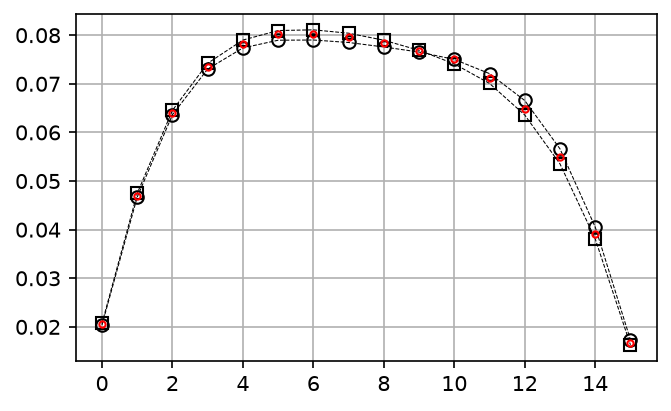

In [7]:
s = 13
regr = Regression()
with open(f'results/res_s{s}_i0.pkl', 'rb') as f:
  res0 = pkl.load(f)
with open(f'results/res_s{s}_i1.pkl', 'rb') as f:
  res1 = pkl.load(f)
res0 = regr.normalize_res(res=res0, val=1.0)
res1 = regr.normalize_res(res=res1, val=1.0)
flux0 = regr.get_avg(res0, val=1.0)
flux1 = regr.get_avg(res1, val=1.0)

I = [flux0, flux1]
res_list = [res0, res1]

new = []
coeffs = []
for f in range(16):
  flux_f, coef = regr.get_new_I(N=500, start=500, F=res_list, I=I, f=f)
  new.append(flux_f[0][0])
  coeffs.append(coef)

new = new / sum(new)
import matplotlib.pyplot as plt
plt.figure(figsize=(5,3), dpi=150)
plt.plot(flux0, 'ko--', markerfacecolor='none', linewidth=0.5)
plt.plot(flux1, 'ks--', markerfacecolor='none', linewidth=0.5)
plt.plot(new, 'r.', markerfacecolor='none', linewidth=0.5)
# plt.plot((flux0+flux1)/sum(flux0+flux1), 'b.', markerfacecolor='none')
plt.grid()

# Try reference solution (half of latest plus half of previous and then all normalized)
try:
  Iref = []
  resRefList = []
  for i in range(6):
    with open(f'reference/res_s{s}_i{i}.pkl', 'rb') as f:
      resRef = pkl.load(f)
    normdRef = regr.normalize_res(res=resRef, val=1.0)
    fluxRef = regr.get_avg(normdRef, val=1.0)
    Iref.append(fluxRef)
    resRefList.append(normdRef)

  newRef = []
  for f in range(16):
    flux_f, coef = regr.get_new_I(N=500, start=500, F=resRefList, I=Iref, f=f)
    newRef.append(flux_f[0][0])
  newRef = np.array(newRef)/1/sum(newRef)
  # newRefV2 = (Iref[-1]*0.3 + Iref[-2]*0.7)
  # newRefV2 /= sum(newRefV2)
  plt.plot(newRef, 'b-', linewidth=0.5)
except:
  print("failed")


In [ ]:
newRef

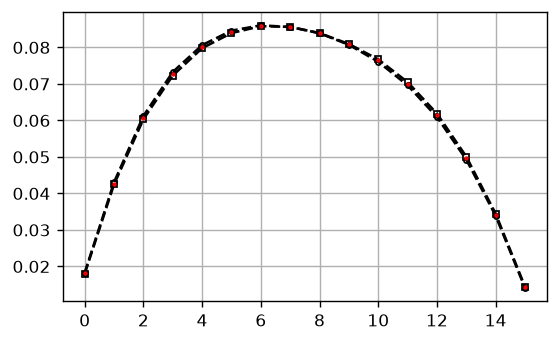

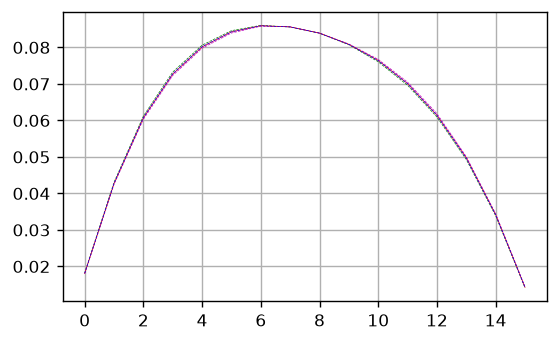

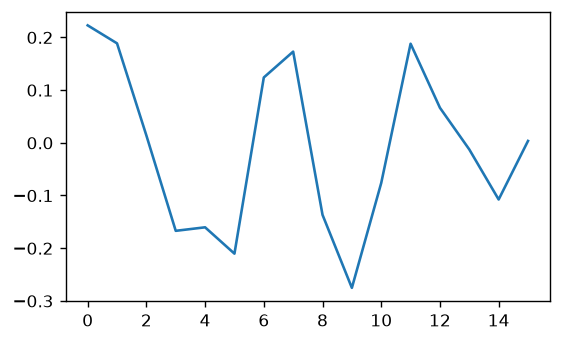

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,3), dpi=125)
plt.plot(flux0, 'ko--', markerfacecolor='none', markersize=3)
plt.plot(flux1, 'ks--', markerfacecolor='none', markersize=3)
plt.plot(new, 'r.', markerfacecolor='none', markersize=3)
plt.grid()

plt.figure(figsize=(5,3), dpi=125)
plt.plot(flux0, 'g--', markerfacecolor='none', linewidth=0.4)
plt.plot(flux1, 'm--', markerfacecolor='none', linewidth=0.4)
plt.plot(new, 'r-', markerfacecolor='none', linewidth=0.4)
plt.plot(flux0/2 + flux1/2, 'b--', linewidth=0.4)
plt.grid()

plt.figure(figsize=(5,3), dpi=125,)
plt.plot(coeffs)

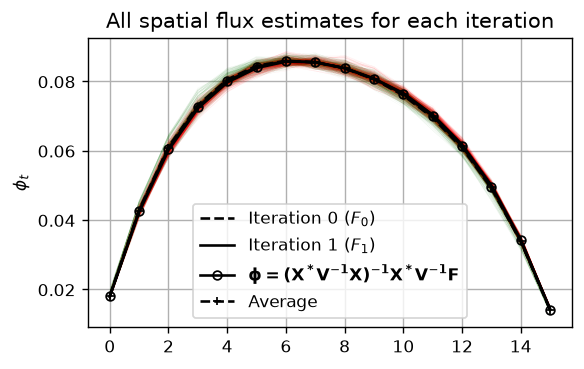

In [5]:

plt.figure(figsize=(5,3), dpi=125)
for key in range(500,1000):
  plt.plot(res0[key], 'g-', linewidth=0.1, alpha=0.1)
  # plt.plot(res1[key], 'r-', linewidth=1, alpha=0.25)
for key in range(500,1000):
  plt.plot(res1[key], 'r-', linewidth=0.1, alpha=0.1)
plt.plot(flux0, 'k--', label=r'Iteration 0 $(F_0)$')
plt.plot(flux1, 'k-', label=r'Iteration 1 $(F_1)$')
plt.plot(new, 'ko-', markersize=5, markerfacecolor='none', label=r'$\mathbf{\phi=(X^* V^{-1} X)^{-1}X^* V^{-1} F}$')
plt.plot(flux0/2 + flux1/2, 'k+--', markersize=5, markerfacecolor='none', label=r'Average')
plt.grid()
plt.title('All spatial flux estimates for each iteration')
plt.ylabel(r'$\phi_t$')
plt.legend()

the matrix V is
[[1.69208231e-07 6.15410572e-09]
 [6.15410572e-09 1.92946167e-07]]
the correlation coeff =  0.03405933250888928

The matrix is:  [[0.53392625 0.46607375]] 

the matrix V is
[[5.77479718e-07 1.46691075e-07]
 [1.46691075e-07 6.20487550e-07]]
the correlation coeff =  0.24505794433784472

The matrix is:  [[0.52377213 0.47622787]] 

the matrix V is
[[8.72603144e-07 3.35710029e-07]
 [3.35710029e-07 1.00756913e-06]]
the correlation coeff =  0.35802924383899976

The matrix is:  [[0.55582864 0.44417136]] 

the matrix V is
[[1.37504502e-06 6.02191291e-07]
 [6.02191291e-07 1.70907480e-06]]
the correlation coeff =  0.3928217043157776

The matrix is:  [[0.58885013 0.41114987]] 

the matrix V is
[[1.45598534e-06 6.74182540e-07]
 [6.74182540e-07 2.02177232e-06]]
the correlation coeff =  0.3929460042525522

The matrix is:  [[0.63285173 0.36714827]] 

the matrix V is
[[1.33282285e-06 5.20763623e-07]
 [5.20763623e-07 1.45123721e-06]]
the correlation coeff =  0.37444257377516876

The matr

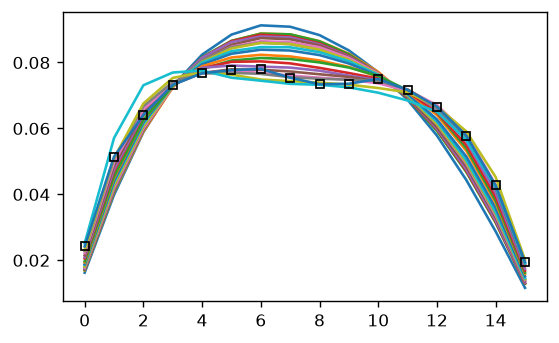

In [6]:
plt.figure(figsize=(5,3), dpi=125)
for this in range(21):
  with open(f'results/res_s{this}_i0.pkl', 'rb') as f:
    res0 = pkl.load(f)
  with open(f'results/res_s{this}_i1.pkl', 'rb') as f:
    res1 = pkl.load(f)
  res0 = regr.normalize_res(res=res0, val=1.0)
  res1 = regr.normalize_res(res=res1, val=1.0)
  flux0 = regr.get_avg(res0, val=1.0)
  flux1 = regr.get_avg(res1, val=1.0)

  I = [flux0, flux1]
  res_list = [res0, res1]

  new = []
  coeffs = []

  for f in range(16):
    flux_f, coef = regr.get_new_I(N=500, start=500, F=res_list, I=I, f=f)
    new.append(flux_f[0][0])
  plt.plot(new/sum(new))
plt.plot(new/sum(new), 'ks', markersize=5, markerfacecolor='none')